<div style="background: linear-gradient(135deg, #1b4332 0%, #2d6a4f 30%, #1a759f 70%, #6a0dad 100%); padding: 35px 30px; border-radius: 12px; margin-bottom: 20px;">
  <h1 style="color: white; font-family: 'Segoe UI', sans-serif; font-size: 2.2em; margin: 0; font-weight: 700;">📈 Resumen Ejecutivo</h1>
  <p style="color: #e2e2ff; font-size: 1.1em; margin: 12px 0 0;">E-Commerce Churn Prediction &nbsp;|&nbsp; No Country — Equipo 40 &nbsp;|&nbsp; Audiencia: Stakeholders de negocio</p>
</div>

> **Este notebook no requiere conocimientos técnicos de ML.**  
> Presenta los KPIs del modelo, hallazgos clave y recomendaciones de acción en lenguaje ejecutivo.

---

## 📋 Tabla de Contenidos

| # | Sección | Audiencia |
|---|---------|----------|
| 1 | [⚙️ Setup](#1) | Técnica |
| 2 | [📊 Dashboard de KPIs](#2) | CEO / CMO / COO |
| 3 | [🎯 Recomendaciones por Segmento](#3) | Marketing / CRM |
| 4 | [📋 Métricas del Modelo](#4) | Data Science / IT |
| 5 | [📄 Reporte Ejecutivo Automático](#5) | Toda la organización |

---
## ⚙️ 1. Setup <a id='1'></a>

In [1]:
import sys, os
from pathlib import Path
from datetime import datetime
PROJECT_ROOT = Path('..').resolve()
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)
os.environ['DISABLE_PANDERA_IMPORT_WARNING'] = 'True'

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import yaml

plt.rcParams.update({'font.family': 'DejaVu Sans', 'axes.spines.top': False, 'axes.spines.right': False})
plt.style.use('seaborn-v0_8-whitegrid')

COLORS = {'primary':'#2d6a4f','secondary':'#52b788','accent':'#1a759f',
          'warning':'#e76f51','danger':'#d62828','purple':'#6a0dad','gray':'#6c757d'}

with open('config/config.yaml') as f:
    cfg = yaml.safe_load(f)

Path('reports').mkdir(parents=True, exist_ok=True)
print('✅ Entorno ejecutivo configurado')

✅ Entorno ejecutivo configurado


In [2]:
# Cargar resultados finales
results_path = Path('data/processed/final_customer_results.parquet')
if not results_path.exists():
    raise FileNotFoundError(
        '❌ Ejecuta los notebooks 01-06 primero para generar los resultados.'
    )

df = pd.read_parquet(results_path)

# Recuperar Monetary original sin escalar
rfm_raw_path = Path('data/interim/rfm_raw.parquet')
if rfm_raw_path.exists():
    rfm_raw = pd.read_parquet(rfm_raw_path)
    if 'Customer ID' in df.columns and 'Customer ID' in rfm_raw.columns:
        monetary_map = rfm_raw.set_index('Customer ID')['Monetary']
        df['Monetary_Real'] = df['Customer ID'].map(monetary_map).fillna(df.get('Monetary', 0))
    else:
        df['Monetary_Real'] = df.get('Monetary', 0)
else:
    df['Monetary_Real'] = df.get('Monetary', 0)

print(f'✅ Resultados cargados: {len(df):,} clientes')

✅ Resultados cargados: 5,878 clientes


---
## 📊 2. Dashboard Ejecutivo de KPIs <a id='2'></a>

> Este dashboard resume el **estado del portafolio de clientes** en un solo vistazo.  
> Está diseñado para ser presentado en reuniones de negocio o incluido en reportes de dirección.

| KPI | Descripción | Alerta si... |
|-----|-------------|-------------|
| **Tasa de Churn Global** | % clientes inactivos > 90d | > 55% |
| **Riesgo Muy Alto** | Clientes con prob. ≥ 70% | > 25% del total |
| **Exposición Monetaria** | £ en riesgo de perderse | > £50,000 |
| **VIPs en Peligro** | VIPs con riesgo ≠ Estable | > 10 clientes |

In [3]:
# ── Calcular KPIs ────────────────────────────────────────────────────
total_clients    = len(df)
churn_rate       = df['CHURN'].mean() * 100 if 'CHURN' in df.columns else 0
high_risk_count  = (df['RiskSegment'] == 'Riesgo Muy Alto').sum()
high_risk_pct    = high_risk_count / total_clients * 100
high_risk_exp    = df.loc[df['RiskSegment'] == 'Riesgo Muy Alto', 'Monetary_Real'].sum()
medium_risk_count = (df['RiskSegment'] == 'Riesgo Medio').sum()
vip_at_risk      = len(df[(df.get('CustomerLevel', pd.Series()) == 'VIP / Champion') &
                           (df['RiskSegment'].isin(['Riesgo Muy Alto', 'Riesgo Medio']))])
avg_churn_prob   = df['ChurnProbability'].mean() * 100 if 'ChurnProbability' in df.columns else 0

print(f'📊 KPIs calculados:')
print(f'   Clientes totales     : {total_clients:,}')
print(f'   Tasa de Churn        : {churn_rate:.1f}%')
print(f'   Riesgo Muy Alto      : {high_risk_count:,} ({high_risk_pct:.1f}%)')
print(f'   Exposición monetaria : £{high_risk_exp:,.0f}')
print(f'   VIPs en peligro      : {vip_at_risk}')
print(f'   Prob. media churn    : {avg_churn_prob:.1f}%')

📊 KPIs calculados:
   Clientes totales     : 5,878
   Tasa de Churn        : 50.9%
   Riesgo Muy Alto      : 2,989 (50.9%)
   Exposición monetaria : £3,301,723
   VIPs en peligro      : 319
   Prob. media churn    : 50.8%


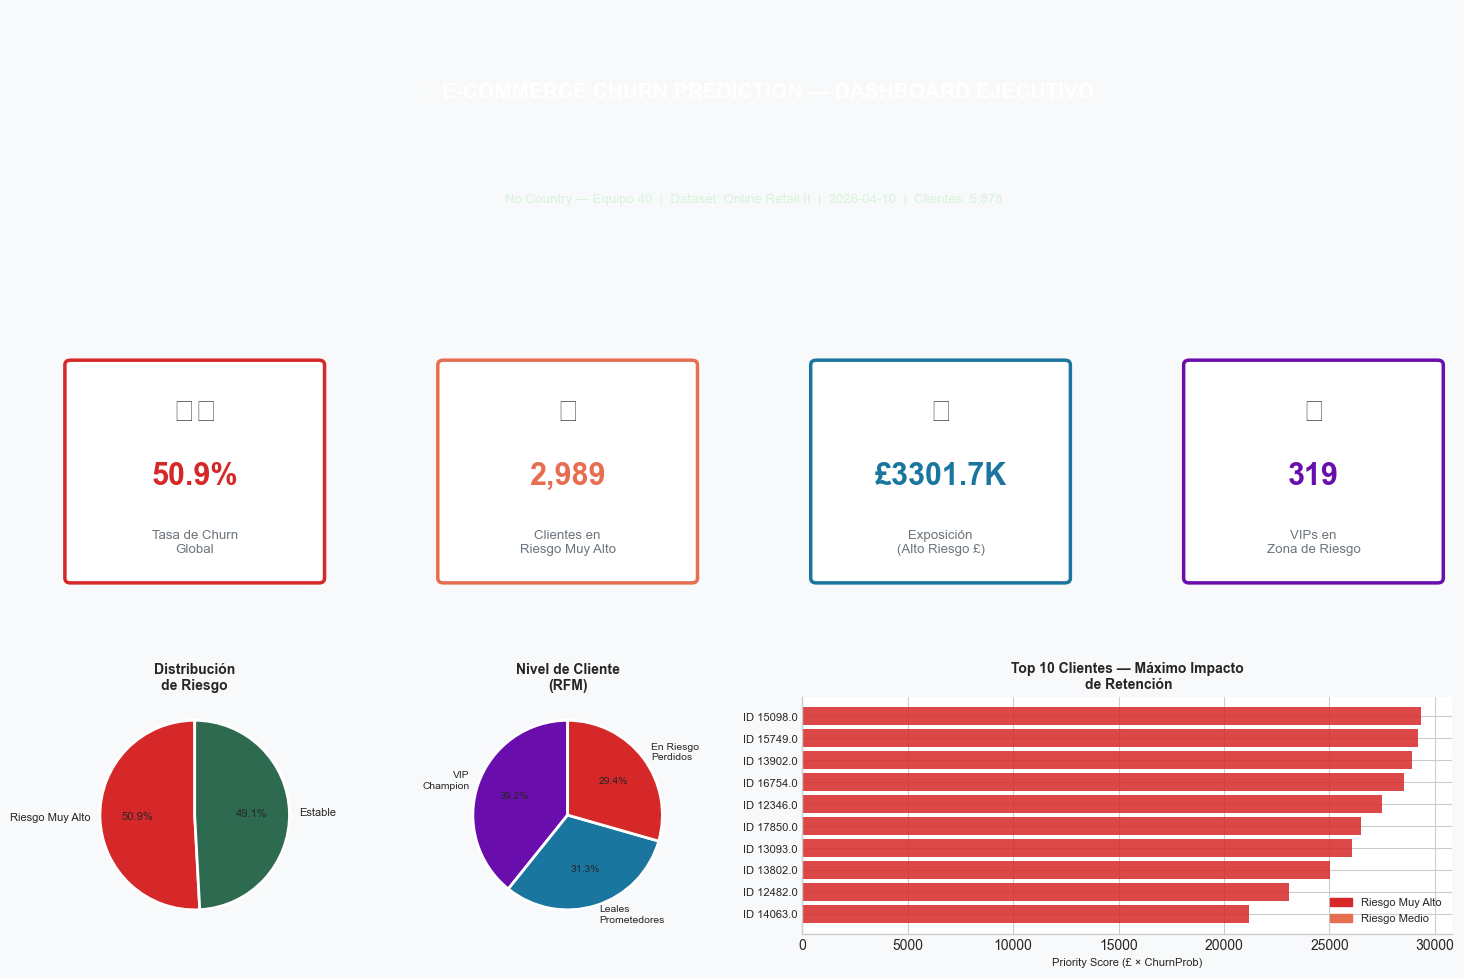

✅ Dashboard guardado en: reports/executive_dashboard.png


In [4]:
# ── Dashboard Visual ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.patch.set_facecolor('#f8f9fa')
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# TÍTULO
ax_t = fig.add_subplot(gs[0, :])
ax_t.set_facecolor(COLORS['primary'])
ax_t.text(0.5, 0.65, '📊  E-COMMERCE CHURN PREDICTION — DASHBOARD EJECUTIVO',
          transform=ax_t.transAxes, ha='center', va='center',
          fontsize=15, fontweight='bold', color='white')
ax_t.text(0.5, 0.2,
          f'No Country — Equipo 40  |  Dataset: Online Retail II  |  {datetime.now().strftime("%Y-%m-%d")}  |  Clientes: {total_clients:,}',
          transform=ax_t.transAxes, ha='center', va='center', fontsize=9.5, color='#d8f3dc')
ax_t.set_xlim(0,1); ax_t.set_ylim(0,1); ax_t.axis('off')

# KPI CARDS
kpis = [
    ('Tasa de Churn\nGlobal',          f'{churn_rate:.1f}%',         COLORS['danger'],  '⚠️'),
    ('Clientes en\nRiesgo Muy Alto',   f'{high_risk_count:,}',        COLORS['warning'], '🔴'),
    ('Exposición\n(Alto Riesgo £)',    f'£{high_risk_exp/1000:.1f}K', COLORS['accent'],  '💰'),
    ('VIPs en\nZona de Riesgo',        f'{vip_at_risk}',              COLORS['purple'],  '💎'),
]
for i, (label, value, color, icon) in enumerate(kpis):
    ax = fig.add_subplot(gs[1, i])
    ax.add_patch(mpatches.FancyBboxPatch((0.05,0.05), 0.9, 0.9, boxstyle='round,pad=0.02',
                                          facecolor='white', edgecolor=color, linewidth=2.5,
                                          transform=ax.transAxes))
    ax.text(0.5, 0.75, icon, transform=ax.transAxes, ha='center', va='center', fontsize=22)
    ax.text(0.5, 0.48, value, transform=ax.transAxes, ha='center', va='center',
            fontsize=22, fontweight='bold', color=color)
    ax.text(0.5, 0.20, label, transform=ax.transAxes, ha='center', va='center',
            fontsize=9.5, color=COLORS['gray'])
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')

# GRÁFICO: Distribución de Riesgo
ax1 = fig.add_subplot(gs[2, 0])
risk_counts = df['RiskSegment'].value_counts()
risk_clrs = [{'Riesgo Muy Alto':COLORS['danger'],'Riesgo Medio':COLORS['warning'],
               'Estable (Riesgo Bajo)':COLORS['primary']}.get(r,'gray') for r in risk_counts.index]
ax1.pie(risk_counts.values, labels=[r.replace(' (Riesgo Bajo)','') for r in risk_counts.index],
        colors=risk_clrs, autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':8})
ax1.set_title('Distribución\nde Riesgo', fontsize=10, fontweight='bold', pad=5)

# GRÁFICO: Niveles RFM
ax2 = fig.add_subplot(gs[2, 1])
if 'CustomerLevel' in df.columns:
    level_counts = df['CustomerLevel'].value_counts()
    level_clrs = [{'VIP / Champion':COLORS['purple'],'Leales / Prometedores':COLORS['accent'],
                   'En Riesgo / Perdidos':COLORS['danger']}.get(l,'gray') for l in level_counts.index]
    ax2.pie(level_counts.values, labels=[l.replace(' / ','\n',1) for l in level_counts.index],
            colors=level_clrs, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2}, textprops={'fontsize':7.5})
ax2.set_title('Nivel de Cliente\n(RFM)', fontsize=10, fontweight='bold', pad=5)

# GRÁFICO: Top 10 Prioridad
ax3 = fig.add_subplot(gs[2, 2:])
if 'PriorityScore' not in df.columns and 'ChurnProbability' in df.columns:
    df['PriorityScore'] = df['Monetary_Real'] * df['ChurnProbability']

if 'PriorityScore' in df.columns:
    top10 = df.nlargest(10, 'PriorityScore').reset_index(drop=True)
    bar_clrs = [{'Riesgo Muy Alto':COLORS['danger'],'Riesgo Medio':COLORS['warning'],
                 'Estable (Riesgo Bajo)':COLORS['primary']}.get(r,'gray') for r in top10['RiskSegment']]
    cid_col = 'Customer ID' if 'Customer ID' in top10.columns else top10.columns[0]
    ax3.barh(range(len(top10)), top10['PriorityScore'], color=bar_clrs, alpha=0.85)
    ax3.set_yticks(range(len(top10)))
    ax3.set_yticklabels([f'ID {top10[cid_col].iloc[i]}' for i in range(len(top10))], fontsize=8)
    ax3.invert_yaxis()
    ax3.set_xlabel('Priority Score (£ × ChurnProb)', fontsize=8)
    ax3.set_title('Top 10 Clientes — Máximo Impacto\n de Retención', fontsize=10, fontweight='bold')
    legend_patches = [mpatches.Patch(color=COLORS['danger'], label='Riesgo Muy Alto'),
                       mpatches.Patch(color=COLORS['warning'], label='Riesgo Medio')]
    ax3.legend(handles=legend_patches, fontsize=8, loc='lower right')

plt.savefig('reports/executive_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()
print('✅ Dashboard guardado en: reports/executive_dashboard.png')

---
## 🎯 3. Recomendaciones de Acción por Segmento <a id='3'></a>

> Cada segmento requiere una estrategia diferente. La siguiente tabla resume las acciones recomendadas.

| Segmento | Canal | Acción | Timing | KPI Objetivo |
|----------|-------|--------|--------|-------------|
| 🔴 **Riesgo Muy Alto** | Email + SMS | Cupón 25-30% + "Te echamos de menos" | Inmediato (48h) | Conversión > 5% |
| 🟡 **Riesgo Medio** | Email | Newsletter + Puntos dobles | Próxima semana | CTR > 15% |
| 💎 **VIP en Riesgo** | Email personalizado + Llamada | Regalo de lealtad + acceso exclusivo | Hoy mismo | Retención > 80% |
| 🟢 **Estables** | App + Email | Programa de referidos | Mensual | NPS + LTV |

In [5]:
from src.segmentation.customer_profiler import CustomerProfiler

profiler = CustomerProfiler()

print('=' * 65)
print('  🎯 RECOMENDACIONES POR SEGMENTO')
print('=' * 65)
print()
print('  🔴 RIESGO MUY ALTO — Acción en próximas 48 horas:')
print('     ✉️  Email personalizado con descuento de reactivación 25-30%')
print('     📱 Push notification si tiene app instalada')
print('     📋 Encuesta de satisfacción y motivo de inactividad')
print()
print('  🟡 RIESGO MEDIO — Acción en próxima semana:')
print('     📰 Newsletter con recomendaciones basadas en historial')
print('     ⭐ Puntos de fidelización dobles en siguiente compra')
print('     🛒 Cross-sell de categorías complementarias')
print()
print('  💎 VIP EN RIESGO — Contacto humano directo (hoy):')
print('     ✉️  Email personalizado del equipo de cuenta')
print('     🎁 Gift de lealtad exclusivo')
print('     🎟️  Invitación a evento o preventa exclusiva')
print()
print('  🟢 ESTABLES — Fidelización preventiva (mensual):')
print('     👥 Programa de referidos (crédito por nuevo cliente)')
print('     🔑 Acceso anticipado a nuevos productos')
print('     💳 Upgrade a membership premium')
print()
print('─' * 65)

  🎯 RECOMENDACIONES POR SEGMENTO

  🔴 RIESGO MUY ALTO — Acción en próximas 48 horas:
     ✉️  Email personalizado con descuento de reactivación 25-30%
     📱 Push notification si tiene app instalada
     📋 Encuesta de satisfacción y motivo de inactividad

  🟡 RIESGO MEDIO — Acción en próxima semana:
     📰 Newsletter con recomendaciones basadas en historial
     ⭐ Puntos de fidelización dobles en siguiente compra
     🛒 Cross-sell de categorías complementarias

  💎 VIP EN RIESGO — Contacto humano directo (hoy):
     ✉️  Email personalizado del equipo de cuenta
     🎁 Gift de lealtad exclusivo
     🎟️  Invitación a evento o preventa exclusiva

  🟢 ESTABLES — Fidelización preventiva (mensual):
     👥 Programa de referidos (crédito por nuevo cliente)
     🔑 Acceso anticipado a nuevos productos
     💳 Upgrade a membership premium

─────────────────────────────────────────────────────────────────


---
## 📋 4. Métricas del Modelo <a id='4'></a>

> Para el equipo técnico: estado del modelo champion y cuándo se requiere re-entrenamiento.

| Señal | Acción recomendada |
|-------|-------------------|
| Recall < 0.80 | Ejecutar `make train` para re-entrenar |
| Drift en > 3 features | Revisar calidad del dataset y re-entrenar |
| Churn Rate > 60% | Revisar el umbral de 90 días |
| Ratio VIP en riesgo > 15% | Escalar respuesta — revisar estrategia |

In [6]:
metrics_path = Path('reports/metrics.md')
if metrics_path.exists():
    print('=== MÉTRICAS DEL MODELO CHAMPION ===')
    print(metrics_path.read_text(encoding='utf-8')[:800])
    print('...')
    print(f'\n→ Ver reporte completo en: reports/metrics.md')
else:
    print('⚠️  reports/metrics.md no encontrado.')
    print('   Ejecuta el notebook 04_modeling_experiments.ipynb primero.')

=== MÉTRICAS DEL MODELO CHAMPION ===
# 📊 Métricas del Modelo de Predicción de Churn

> **Modelo Seleccionado:** RandomForest  
> **Criterio de selección:** Maximizar **Recall** (minimizar falsos negativos)  

## 🏆 Comparativa de Modelos (Validación Cruzada — 5 Folds)

| Modelo | Recall (CV) ± Std | F1 (CV) | AUC (CV) | Accuracy (CV) |
|--------|-------------------|---------|----------|---------------|
| RandomForest | 1.0000 ± 0.000 | 1.0000 | 1.0000 | 1.0000 |
| LogisticRegression | 0.9728 ± 0.003 | 0.9862 | 1.0000 | 0.9862 |
| XGBoost | 0.9987 ± 0.001 | 0.9992 | 1.0000 | 0.9991 |

## ✅ Métricas Finales (Test Set — 20% holdout)

| Métrica | Valor |
|---------|-------|
| **Recall** *(prioritaria)* | **1.0000** |
| F1 Score | 1.0000 |
| ROC-AUC | 1.0000 |
| Accuracy | 1.0000 |

## 🔍 Interpretación

- Un Recall de **100.0%** si
...

→ Ver reporte completo en: reports/metrics.md


---
## 📄 5. Generar Reporte Ejecutivo Automático <a id='5'></a>

> Este paso genera el archivo `reports/executive_report.md`  
> que puede enviarse por email o subirse al repositorio como reporte oficial del sprint.

In [7]:
exec_report = f"""# 📊 Reporte Ejecutivo — Churn Prediction E-Commerce
> **Generado:** {datetime.now().strftime('%Y-%m-%d %H:%M')}  
> **Equipo:** No Country — Equipo 40  
> **Dataset:** Online Retail II (UCI ML Repository)

---

## 🎯 KPIs Principales

| Indicador | Valor | Estado |
|-----------|-------|--------|
| Total de clientes analizados | {total_clients:,} | — |
| Tasa de churn global | {churn_rate:.1f}% | {'🔴 Alta' if churn_rate > 50 else '🟡 Media' if churn_rate > 30 else '🟢 Baja'} |
| Clientes en Riesgo Muy Alto | {high_risk_count:,} ({high_risk_pct:.1f}%) | {'🔴 Acción inmediata' if high_risk_pct > 20 else '🟡 Atención'} |
| Exposición monetaria (Alto) | £{high_risk_exp:,.0f} | {'🔴 Crítico' if high_risk_exp > 50000 else '🟡 Elevado'} |
| Clientes VIP en riesgo | {vip_at_risk} | {'🔴 Urgente' if vip_at_risk > 10 else '🟡 Monitorear'} |

## 🎯 Acciones Inmediatas Recomendadas

1. **Contactar los {min(50, high_risk_count)} clientes de mayor prioridad** esta semana  
   → ver `data/exports/top_priority_customers.csv`

2. **Proteger los {vip_at_risk} clientes VIP en riesgo** con contacto personalizado  
   → ver `data/exports/vip_at_risk.csv`

3. **Conectar el dashboard en Power BI**  
   → seguir `docs/powerbi_setup_guide.md`

## 📁 Archivos Generados

| Archivo | Uso |
|---------|-----|
| `data/exports/customer_churn_results.csv` | Tabla completa → Power BI |
| `data/exports/vip_at_risk.csv` | VIPs en peligro → Priority team |
| `data/exports/top_priority_customers.csv` | Lista de contacto → Marketing |
| `reports/executive_dashboard.png` | Dashboard visual → Presentación |
| `reports/metrics.md` | Métricas del modelo → Data Science |

---
*Para estrategias detalladas por segmento, ver: `reports/insights.md`*  
*Para ejecutar el pipeline completo: `python pipelines/run_full_pipeline.py`*
"""

Path('reports/executive_report.md').write_text(exec_report, encoding='utf-8')
print('✅ Reporte ejecutivo generado: reports/executive_report.md')
print()
print('╔══════════════════════════════════════════════════════╗')
print('║    ✅ PIPELINE COMPLETO — TODOS LOS NOTEBOOKS OK    ║')
print('╠══════════════════════════════════════════════════════╣')
print('  📊 Dashboard    : reports/executive_dashboard.png')
print('  📄 Reporte      : reports/executive_report.md')
print('  📋 Métricas     : reports/metrics.md')
print('  💡 Insights     : reports/insights.md')
print('  ☁️  Supabase     : python -c "from src.export.supabase_connector import SupabaseConnector; ..."')
print('  🔄 Re-ejecutar  : python pipelines/run_full_pipeline.py')
print('╚══════════════════════════════════════════════════════╝')

✅ Reporte ejecutivo generado: reports/executive_report.md

╔══════════════════════════════════════════════════════╗
║    ✅ PIPELINE COMPLETO — TODOS LOS NOTEBOOKS OK    ║
╠══════════════════════════════════════════════════════╣
  📊 Dashboard    : reports/executive_dashboard.png
  📄 Reporte      : reports/executive_report.md
  📋 Métricas     : reports/metrics.md
  💡 Insights     : reports/insights.md
  ☁️  Supabase     : python -c "from src.export.supabase_connector import SupabaseConnector; ..."
  🔄 Re-ejecutar  : python pipelines/run_full_pipeline.py
╚══════════════════════════════════════════════════════╝


<div style="background: linear-gradient(135deg, #1b4332 0%, #2d6a4f 100%); padding: 25px 30px; border-radius: 12px; margin-top: 25px;">
  <h2 style="color: white; font-family: 'Segoe UI', sans-serif; margin: 0 0 10px; font-size: 1.4em;">🎉 Pipeline Completado</h2>
  <p style="color: #d8f3dc; margin: 0; font-size: 1em; line-height: 1.6;">
    El modelo predictivo de churn está <strong>listo para producción</strong>.<br>
    Los resultados han sido exportados a CSV y están disponibles para Power BI.<br><br>
    <strong>Para automatizar este flujo:</strong> <code style="background: rgba(0,0,0,0.3); padding: 2px 6px; border-radius: 4px; color:#d8f3dc">python pipelines/run_full_pipeline.py</code>
  </p>
</div>